# Creating Plots for Data Viz 

In [107]:
#packages
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [119]:
#loading data
df = pd.read_parquet('/Users/pdeguz01/Documents/git/IDS705_TeamPandas/00-Data/Data Viz Data/MergedDataset.parquet')

In [120]:
#df details
col_list = df.columns.tolist()

In [121]:
print(col_list)

['INSPECTION_DATE', 'STORE_NAME', 'STREET_ADDRESS', 'CITY', 'ZIP5', 'SERVICE_DESCRIPTION', 'SCORE', 'GRADE', 'STREET_ADDRESS_LINE2', 'INSPDATE_YEAR', 'Latitude', 'Longitude', 'Accuracy Score', 'Accuracy Type', 'Number', 'Street', 'Unit Type', 'Unit Number', 'City', 'State', 'County', 'Zip', 'Country', 'Source', 'geometry', 'buffer', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'PRIMARY_CENSUSTRACT', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'AVG_INCOME_NEARBY_TRACTS', 'AVG_HH_SIZE_NEARBY_TRACTS', 'AVG_RENT_NEARBY_TRACTS', 'AVG_POP_NEARBY_TRACTS', 'ST_ABBR', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'E_HU', 'E_HH', 'E_POV150', 'E_UNEMP', 'E_HBURD', 'E_NOHSDP', 'E_UNINSUR', 'E_AGE65', 'E_AGE17', 'E_DISABL', 'E_SNGPNT', 'E_LIMENG', 'E_MINRTY', 'E_MUNIT', 'E_MOBILE', 'E_CROWD', 'E_NOVEH', 'E_GROUPQ', 'EP_POV150', 'EP_UNEMP', 'EP_HBURD', 'EP_NOHSDP', 'EP_UNINSUR', 'EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_LIMENG', 'EP_MINRTY', 'EP_MUNIT', 'EP

In [125]:
#cleaning vars
df["SCORE"] = pd.to_numeric(df["SCORE"], errors="coerce")
df["RPL_THEMES"] = pd.to_numeric(df["RPL_THEMES"], errors="coerce")
df["RPL_THEMES"] = df["RPL_THEMES"].replace(-999, pd.NA)


# Plot 1

A density bar plot for the count of how many not passing restaurants there are in social vulnerable areas
So like a histogram (but data is filtered to restaurants that don’t pass, and the y axis is the number of restaurants and x axis is the Social Vulnerability Index scores)


In [123]:
#filter df
plotting_cols = ["INSPECTION_DATE", "STORE_NAME", "SCORE", "RPL_THEMES"]
df_filtered = df[plotting_cols]


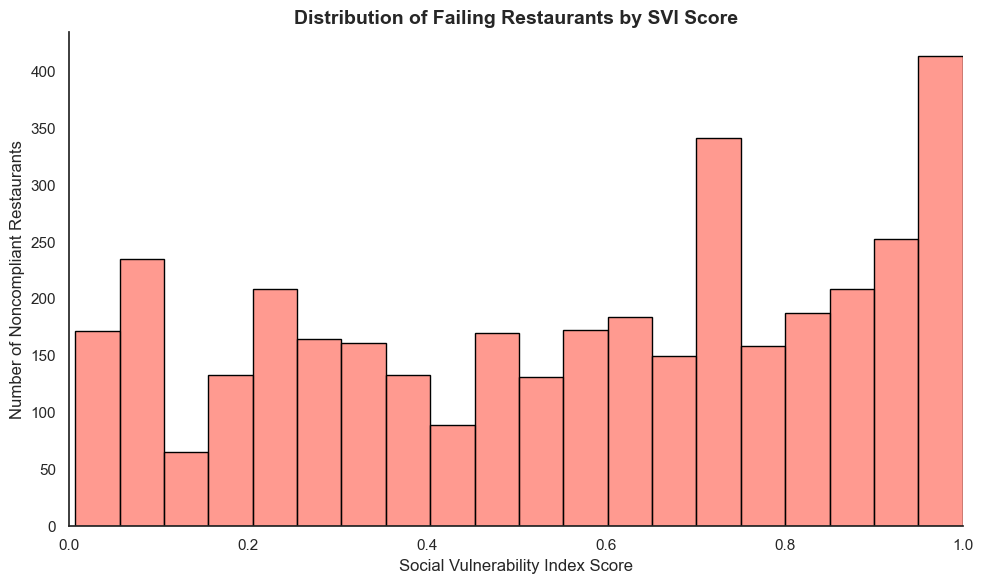

In [129]:
# Convert RPL_THEMES to numeric and filter to failing
df_fail = df[df["SCORE"] < 90].dropna(subset=["RPL_THEMES"])
df_fail = df_fail[plotting_cols]
plt.figure(figsize=(10,6))
sns.set_style("white")

sns.histplot(
    data=df_fail,
    x="RPL_THEMES",
    bins=20,
    color="#FF6F61",       
    edgecolor="black",      
    alpha=0.7               
)
plt.xlabel("Social Vulnerability Index Score", fontsize=12)
plt.ylabel("Number of Noncompliant Restaurants", fontsize=12)
plt.title("Distribution of Failing Restaurants by SVI Score", fontsize=14, weight="bold")
sns.despine()
plt.xlim(0,1)               
plt.tight_layout()
plt.show()


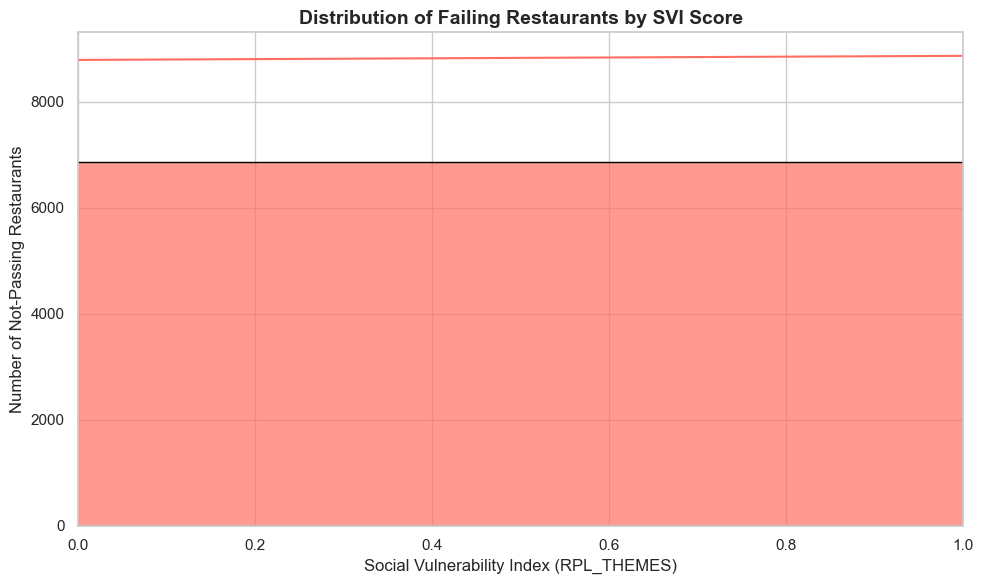

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure RPL_THEMES is numeric and drop NA
df["RPL_THEMES"] = pd.to_numeric(df["RPL_THEMES"], errors="coerce")
df_fail = df[df["SCORE"] <= 90].dropna(subset=["RPL_THEMES"])

# Set a nice Seaborn style
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

# Histogram with KDE overlay
sns.histplot(
    data=df_fail,
    x="RPL_THEMES",
    bins=20,
    kde=True,               # adds smooth density curve
    color="#FF6F61",        # nice coral color
    edgecolor="black",      # black borders for bars
    alpha=0.7               # slightly transparent bars
)

plt.xlabel("Social Vulnerability Index (RPL_THEMES)", fontsize=12)
plt.ylabel("Number of Not-Passing Restaurants", fontsize=12)
plt.title("Distribution of Failing Restaurants by SVI Score", fontsize=14, weight="bold")

plt.xlim(0,1)               # ensure x-axis is 0–1
plt.tight_layout()
plt.show()


# Plot 2

Maybe a plot with like 5-10 top Census tracts with the most poorly performing restaurants (group by Census tracts, rank by # of restaurants that did not pass inspection)
Incorporate # of violations


In [114]:
#prep data

In [115]:
#plotting